# Depth-space Meridional Overturning Circulation from ECCOv4r4 with `sectionate`

This notebook computes the global meridional overturning streamfunction $\psi(\mathrm{latitude}, \mathrm{depth})$ from **ECCOv4r4** output on its **native lat-lon-cap (LLC90)** grid. It is the first end-to-end demonstration of three capabilities added to `sectionate` for this kind of grid, used together on real model output (so it doubles as a validation):

- **multi-tile grids** (`face_connections`): LLC90 is a 13-tile lat-lon-cap grid, and sections are now traced *across* tile seams;
- **native MITgcm/ECCO 'left'-staggered grids**: the native vorticity-on-SW-corner staggering is consumed directly (no conversion to a symmetric 'outer' grid);
- **latitude-circle sections** (`curve="latitude circle"`): tracing constant-latitude paths that march in longitude, rather than great circles.

The recipe is:
1. trace a global latitude-circle section at each of a range of latitudes with `sectionate.grid_section(grid, lons, lats, curve="latitude circle")`;
2. compute the meridional volume transport across each section per depth level with `sectionate.transports.convergent_transport`;
3. cumulatively integrate in depth to obtain $\psi(\mathrm{lat}, z)$;
4. plot $\psi(\mathrm{lat}, z)$.

The required ECCO geometry and volume-flux files are a small, unmodified subset of NASA's ECCO V4r4 state estimate, redistributed on [Zenodo](https://doi.org/10.5281/zenodo.21051424) so this example runs without a NASA Earthdata Login. They download automatically (and are checked against their published MD5s) the first time you run the next cell. The original data are produced by the ECCO Consortium and distributed by NASA PO.DAAC; please cite the original sources — see the [Zenodo record](https://doi.org/10.5281/zenodo.21051424) for the per-dataset DOIs and citations.

## Import packages

In [1]:
import warnings
import numpy as np
import xarray as xr
import matplotlib.pyplot as plt

import sectionate
from sectionate.gridutils import corner_position, get_facedim
print(f"Sectionate version: {sectionate.__version__}")

Sectionate version: 0.3.3


## Load the native ECCO LLC90 grid and volume transports

`load_ECCO_MOC_grid` (see `load_example_ECCO_grid.py`) fetches the ECCO geometry and the twelve 2010 monthly 3-D volume-flux files from [Zenodo](https://doi.org/10.5281/zenodo.21051424) (reusing any already under `../data/`) and returns a native ('left'-staggered), multi-tile `xgcm.Grid`. Its dataset carries the volume transports across the U (west) and V (south) cell faces,

$$ \texttt{utr} = \texttt{UVELMASS}\cdot \texttt{dyG}\cdot \texttt{drF}, \qquad \texttt{vtr} = \texttt{VVELMASS}\cdot \texttt{dxG}\cdot \texttt{drF}, $$

in $\mathrm{m^3\,s^{-1}}$ (the mass-weighted ECCO velocities already include the open-cell fraction `hFac`, so multiplying by the full face width and layer thickness gives the transport).

In [2]:
from load_example_ECCO_grid import load_ECCO_MOC_grid

grid = load_ECCO_MOC_grid()  # time-mean over the twelve months of 2010
ds = grid._ds

# Sanity-check the prerequisites for the three new capabilities:
print("vorticity corner position:", corner_position(grid))   # 'left' (native MITgcm/ECCO)
print("face (tile) dimension    :", get_facedim(grid))       # 'tile' -> multi-tile grid
print("number of tiles          :", ds.sizes['tile'])
print("vertical levels          :", ds.sizes['k'],
      f"(depths {float(ds.Z[0]):.0f} m to {float(ds.Z[-1]):.0f} m)")
print("months in time average   :", ds.sizes['time'])

assert corner_position(grid) == 'left'  # consumed natively; no 'symmetrize' step

vorticity corner position: left
face (tile) dimension    : tile
number of tiles          : 13
vertical levels          : 50 (depths -5 m to -5906 m)
months in time average   : 12


## Meridional transport across a global latitude circle

Each latitude circle is traced as a **closed** loop spanning the full 360° of longitude. Because every section segment must span **less than 180°** of longitude (otherwise the east/west direction is ambiguous and `grid_section` raises), we subdivide each circle into four 90° arcs: $0°\to90°\to180°\to270°\to360°$.

On this multi-tile grid `grid_section` returns the per-point **face index** `f_c` in addition to `(i_c, j_c)`. `convergent_transport` then computes the signed volume transport normal to the section at each depth level; since a global latitude circle encloses a polar cap, the default `positive_in=True` makes convergence point *into* that cap, so we negate it to get **northward** transport and sum along the section.

In [3]:
Sv = 1e-6  # m^3/s -> Sverdrup

def northward_transport_per_level(grid, lat):
    """Time-mean northward volume transport (Sv) per depth level across the global
    latitude circle at `lat`, using sectionate's latitude-circle sections."""
    section_lons = [0., 90., 180., 270., 360.]   # four <180-degree arcs -> closed circle
    section_lats = [lat] * len(section_lons)
    i_c, j_c, f_c, _, _ = sectionate.grid_section(
        grid, section_lons, section_lats, curve="latitude circle"
    )
    conv = sectionate.transports.convergent_transport(
        grid, i_c, j_c, f_c=f_c,
        utr="utr", vtr="vtr",
        layer=None, interface=None,   # vertical coordinate is the depth dimension 'k'
    )
    # convergence is "inward" to the enclosed polar cap; negate -> northward, then
    # integrate along the section at each depth level and average over time.
    return (-conv["conv_mass_transport"].sum("sect")).mean("time") * Sv

## Compute the overturning streamfunction $\psi(\mathrm{lat}, z)$

We evaluate the northward transport at a range of latitudes and cumulatively integrate from the surface downward. The loop over latitudes (each tracing four sub-180° arcs across the 13 tiles) dominates the run time; the transport extraction itself is cheap.

In [4]:
latitudes = np.arange(-70., 71., 2.5)

# Latitude circles are closed sections, so `convergent_transport` uses the polygon
# (cap) orientation; silence only the expected per-call informational warnings.
with warnings.catch_warnings():
    warnings.simplefilter("ignore")
    transport = xr.concat(
        [northward_transport_per_level(grid, lat).compute() for lat in latitudes],
        dim=xr.DataArray(latitudes, dims="lat", name="lat"),
    )

# psi(z) = cumulative northward transport from the surface down to depth z.
psi = transport.cumsum("k").assign_coords(Z=ds["Z"])
psi.name = "overturning_streamfunction"
psi.attrs = {"units": "Sv", "long_name": "Meridional overturning streamfunction"}
print("psi range (Sv):", float(psi.min()), "to", float(psi.max()))

psi range (Sv): -58.09992975038242 to 53.35870875408872


## Plot $\psi(\mathrm{lat}, z)$

The depth-space global MOC shows the expected features: a **positive upper cell** (North Atlantic Deep Water formation and its upper-ocean return), a **negative abyssal cell** (Antarctic Bottom Water), the wind-driven subtropical cells near the equator, and the strong Southern-Ocean Deacon cell. (The color scale saturates the strongest Southern-Ocean and equatorial cells.)

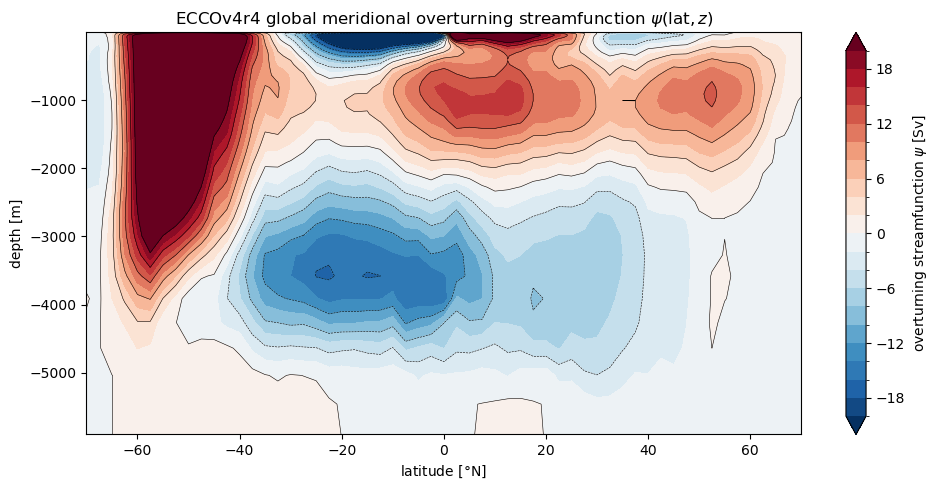

In [5]:
fig, ax = plt.subplots(figsize=(10, 5))
psi.plot.contourf(
    x="lat", y="Z", ax=ax,
    levels=np.arange(-20, 21, 2), cmap="RdBu_r", extend="both",
    cbar_kwargs={"label": r"overturning streamfunction $\psi$ [Sv]"},
)
psi.plot.contour(
    x="lat", y="Z", ax=ax,
    levels=np.arange(-20, 21, 4), colors="k", linewidths=0.4,
)
ax.set_xlabel(r"latitude [$\degree$N]")
ax.set_ylabel("depth [m]")
ax.set_title(r"ECCOv4r4 global meridional overturning streamfunction $\psi(\mathrm{lat}, z)$")
plt.tight_layout();

The same machinery works for any other latitude-circle (or great-circle) section on this native, multi-tile LLC90 grid — e.g. restricting the transport to a single basin, or computing transports across named hydrographic lines — by changing the waypoints passed to `sectionate.grid_section`.